## **CLA Flight Intelligence**

CLA Flight Intelligence — Travel Agency India es una agencia especializada en vuelos nacionales dentro de India, un mercado donde los precios fluctúan de manera constante debido a factores como la aerolínea, la duración del trayecto, el número de escalas y, especialmente, la antelación con la que se realiza la reserva. Para ofrecer a nuestros clientes las mejores opciones posibles, necesitamos comprender cómo evolucionan los precios y anticipar cuándo es más conveniente comprar un billete.

El objetivo del proyecto es desarrollar un modelo de Machine Learning capaz de predecir el precio esperado de un vuelo nacional en India a partir de sus características principales. Esta predicción permite a CLA Flight Intelligence recomendar a los clientes si es un buen momento para reservar, identificar vuelos con precios inusualmente altos o bajos y optimizar las estrategias comerciales y de marketing de la agencia.

Aunque el dataset cubre únicamente vuelos entre el 11 de febrero y el 31 de marzo, incluye la variable más determinante en el pricing aéreo: la antelación de compra (days_left). Esto permite modelar patrones reales de comportamiento del precio en el corto plazo, suficientes para mejorar la toma de decisiones de la agencia y ofrecer recomendaciones basadas en datos.

El modelo resultante ayuda a CLA Flight Intelligence — Travel Agency India a:

- Recomendar el mejor momento para reservar un vuelo dentro de India,
- Detectar oportunidades de compra cuando un precio está por debajo de lo habitual,
- Priorizar rutas y aerolíneas con mejor relación calidad‑precio,
- Mejorar la experiencia del cliente mediante información personalizada y fundamentada en datos.

#### **Paso 0: Importar librerías**

import matplotlib.pyplot as plt
import joblib
import numpy as np
import optuna
import os
import pandas as pd
import re
import seaborn as sns
import sys

from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate, cross_val_score
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin

from scipy import stats

sys.path.append(os.path.abspath("./src/utils"))
import bootcampviztools as bt

pd.options.mode.copy_on_write = True

In [1]:
# ============================================
# LIBRERÍAS NECESARIAS PARA TODO EL PIPELINE
# ============================================

# --- Python estándar ---
import re
import numpy as np
import pandas as pd

# --- Visualización ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Scikit-Learn: Transformadores y Preprocesado ---
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline

# --- Scikit-Learn: Modelos ---
from sklearn.ensemble import RandomForestClassifier

# --- Scikit-Learn: Métricas ---
from sklearn.metrics import f1_score, balanced_accuracy_score, roc_auc_score

# --- Scikit-Learn: Validación ---
from sklearn.model_selection import (
    train_test_split,
    cross_validate,
    KFold
)

# --- XGBoost ---
from xgboost import XGBClassifier

# --- LightGBM ---
from lightgbm import LGBMClassifier

# --- CatBoost (si lo usas) ---
from catboost import CatBoostClassifier

# --- Otros (si los usas en tu notebook) ---
from scipy import stats
import bootcampviztools as bt


#### **Paso 1: Cargar los datos**

In [2]:
df_economy= pd.read_csv("../data/economy.csv")
df_eco=df_economy.copy()
df_business = pd.read_csv("../data/business.csv")
df_bus=df_business.copy()

In [3]:
df_eco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206774 entries, 0 to 206773
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   date        206774 non-null  object
 1   airline     206774 non-null  object
 2   ch_code     206774 non-null  object
 3   num_code    206774 non-null  int64 
 4   dep_time    206774 non-null  object
 5   from        206774 non-null  object
 6   time_taken  206774 non-null  object
 7   stop        206774 non-null  object
 8   arr_time    206774 non-null  object
 9   to          206774 non-null  object
 10  price       206774 non-null  object
dtypes: int64(1), object(10)
memory usage: 17.4+ MB


In [4]:
df_bus.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93487 entries, 0 to 93486
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        93487 non-null  object
 1   airline     93487 non-null  object
 2   ch_code     93487 non-null  object
 3   num_code    93487 non-null  int64 
 4   dep_time    93487 non-null  object
 5   from        93487 non-null  object
 6   time_taken  93487 non-null  object
 7   stop        93487 non-null  object
 8   arr_time    93487 non-null  object
 9   to          93487 non-null  object
 10  price       93487 non-null  object
dtypes: int64(1), object(10)
memory usage: 7.8+ MB


Añado la columna class para separar entre Economy y Business:

In [5]:
df_eco["class"] = "economy"
df_bus["class"] = "business"

In [6]:
df_all=pd.concat([df_eco, df_bus], axis=0, ignore_index=True)

In [7]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300261 entries, 0 to 300260
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   date        300261 non-null  object
 1   airline     300261 non-null  object
 2   ch_code     300261 non-null  object
 3   num_code    300261 non-null  int64 
 4   dep_time    300261 non-null  object
 5   from        300261 non-null  object
 6   time_taken  300261 non-null  object
 7   stop        300261 non-null  object
 8   arr_time    300261 non-null  object
 9   to          300261 non-null  object
 10  price       300261 non-null  object
 11  class       300261 non-null  object
dtypes: int64(1), object(11)
memory usage: 27.5+ MB


#### ETL

Transformer 1: Convertir duración

In [8]:
from sklearn.base import BaseEstimator, TransformerMixin
import re
import numpy as np

class DurationTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        def convert(x):
            h = re.search(r'(\d+)h', x)
            m = re.search(r'(\d+)m', x)
            hours = int(h.group(1)) if h else 0
            minutes = int(m.group(1)) if m else 0
            return hours + minutes/60
        X["duration(h)"] = X["time_taken"].apply(convert)
        return X


Transformer 2: Categorizar horas

In [9]:
class TimeCategoryTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        X["dep_time"] = pd.to_datetime(X["dep_time"], format="%H:%M")
        X["arr_time"] = pd.to_datetime(X["arr_time"], format="%H:%M")

        def categorize(h):
            if 0 <= h < 4: return "Late Night"
            if 4 <= h < 8: return "Early Morning"
            if 8 <= h < 12: return "Morning"
            if 12 <= h < 16: return "Afternoon"
            if 16 <= h < 20: return "Evening"
            return "Night"

        X["dep_time_cat"] = X["dep_time"].dt.hour.apply(categorize)
        X["arr_time_cat"] = X["arr_time"].dt.hour.apply(categorize)
        return X

Transformer 3: Limpiar stops

In [10]:
class StopCleaner(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        def clean(x):
            x = x.lower().strip()
            if "non" in x: return "non-stop"
            m = re.search(r'(\d+)', x)
            if m: return f"{m.group(1)}-stop"
            return "unknown"
        X["stop"] = X["stop"].apply(clean)
        X["stop_num"] = X["stop"].replace({
            "non-stop": 0,
            "1-stop": 1,
            "2-stop": 2
        }).astype(int)
        return X

Transformer 4: Calcular days_left

In [11]:
class DaysLeftTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, scraping_date="10-02-2022"):
        self.scraping_date = pd.to_datetime(scraping_date, format="%d-%m-%Y")
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        X["date"] = pd.to_datetime(X["date"], format="%d-%m-%Y", errors="coerce")
        X["days_left"] = (X["date"] - self.scraping_date).dt.days
        return X


Transformer 5: Eliminar columnas irrelevantes

In [12]:
class ColumnDropper(BaseEstimator, TransformerMixin):
    def __init__(self, cols_to_drop):
        self.cols_to_drop = cols_to_drop
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        return X.drop(columns=[c for c in self.cols_to_drop if c in X.columns])

Transformer 6: Convertir price a float

In [13]:
class PriceToFloat(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()

        # convertir a float
        X["price"] = (
            X["price"]
            .astype(str)
            .str.replace(",", "")
            .astype(float)
        )

        # renombrar con unidades
        X = X.rename(columns={"price": "price (INR)"})

        return X

Tranformer 7: Agrupar las aerolineas

In [14]:
class AirlineGrouper(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.rare_airlines = ["SpiceJet", "StarAir", "Trujet", "AirAsia"]

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X["airline"] = X["airline"].replace(self.rare_airlines, "Other")
        return X

Tranformer 8: Eliminar los duplicados

In [15]:
class DropDuplicates(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        return X.drop_duplicates().reset_index(drop=True)

Pipeline ETL completo dentro de sklearn

In [16]:
df_all.columns

Index(['date', 'airline', 'ch_code', 'num_code', 'dep_time', 'from',
       'time_taken', 'stop', 'arr_time', 'to', 'price', 'class'],
      dtype='object')

In [17]:
cols_to_drop = [
    "dep_time", "arr_time", "date", "time_taken",
    "ch_code", "num_code", "dep_hour", "arr_hour",
    "flight", "stop"
]

etl_pipeline = Pipeline([
    ("price_float", PriceToFloat()),
    ("duration", DurationTransformer()),
    ("time_cat", TimeCategoryTransformer()),
    ("stop_clean", StopCleaner()),
    ("days_left", DaysLeftTransformer()),
    ("drop_cols", ColumnDropper(cols_to_drop)),
    ("airline_group", AirlineGrouper()),
    ("drop_dupes", DropDuplicates()),
])

In [18]:
df_all_clean=etl_pipeline.fit_transform(df_all)

C:\Users\aquin\AppData\Local\Temp\ipykernel_16940\1681845033.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X["stop_num"] = X["stop"].replace({


In [19]:
df_all_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 298192 entries, 0 to 298191
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   airline       298192 non-null  object 
 1   from          298192 non-null  object 
 2   to            298192 non-null  object 
 3   price (INR)   298192 non-null  float64
 4   class         298192 non-null  object 
 5   duration(h)   298192 non-null  float64
 6   dep_time_cat  298192 non-null  object 
 7   arr_time_cat  298192 non-null  object 
 8   stop_num      298192 non-null  int64  
 9   days_left     298192 non-null  int64  
dtypes: float64(2), int64(2), object(6)
memory usage: 22.8+ MB


In [20]:
df_all_clean.isna().sum()

airline         0
from            0
to              0
price (INR)     0
class           0
duration(h)     0
dep_time_cat    0
arr_time_cat    0
stop_num        0
days_left       0
dtype: int64

#### **Paso 2: Mini-EDA**

**Análisis univariante**

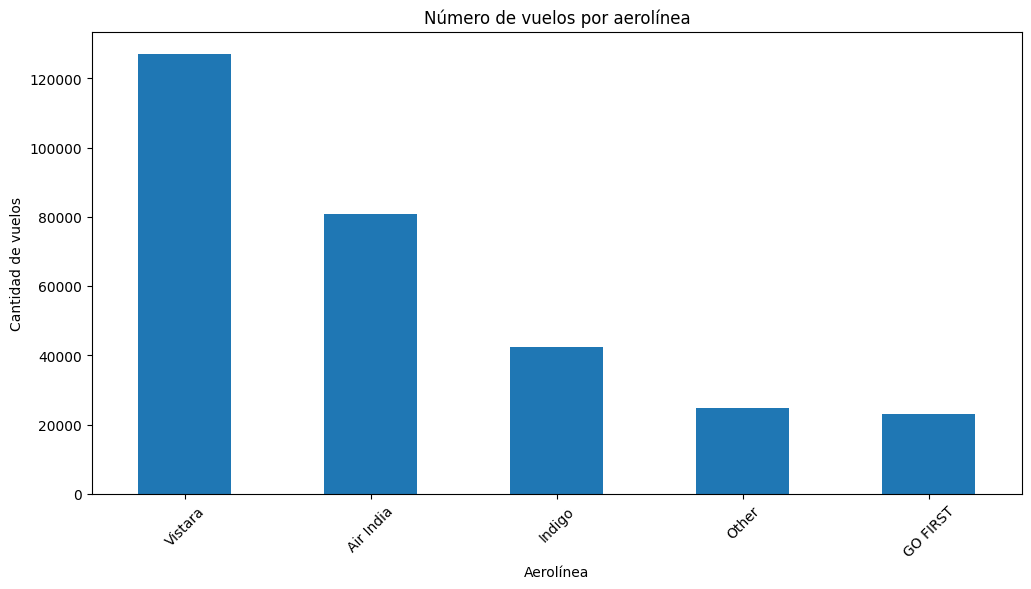

In [21]:
plt.figure(figsize=(12,6))
df_all_clean['airline'].value_counts().plot(kind='bar')
plt.title("Número de vuelos por aerolínea")
plt.xlabel("Aerolínea")
plt.ylabel("Cantidad de vuelos")
plt.xticks(rotation=45)
plt.show()


<Figure size 1200x600 with 0 Axes>

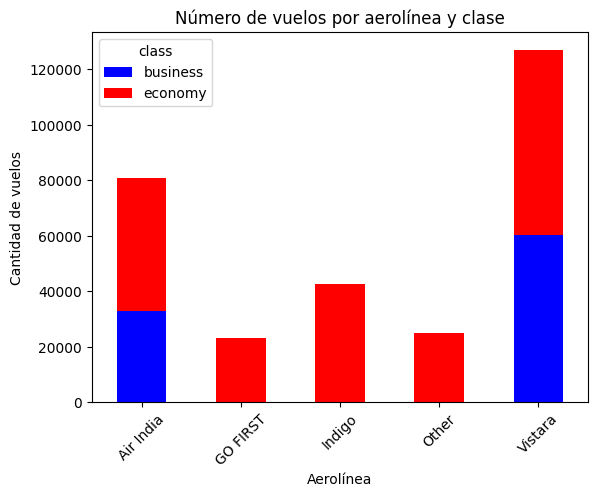

In [22]:
tabla_plot = pd.crosstab(df_all_clean["airline"], df_all_clean["class"])
plt.figure(figsize=(12,6))
tabla_plot.plot(kind='bar', stacked=True, color=["blue", "red"])
plt.title("Número de vuelos por aerolínea y clase")
plt.xlabel("Aerolínea")
plt.ylabel("Cantidad de vuelos")
plt.xticks(rotation=45)
plt.show()


In [23]:
df_all_clean.head(10)

,airline,from,to,price (INR),class,duration(h),dep_time_cat,arr_time_cat,stop_num,days_left
0,Other,Delhi,Mumbai,5953.0,economy,2.166667,Evening,Night,0,1
1,Other,Delhi,Mumbai,5953.0,economy,2.333333,Early Morning,Morning,0,1
2,Other,Delhi,Mumbai,5956.0,economy,2.166667,Early Morning,Early Morning,0,1
3,Vistara,Delhi,Mumbai,5955.0,economy,2.250000,Morning,Afternoon,0,1
4,Vistara,Delhi,Mumbai,5955.0,economy,2.333333,Morning,Morning,0,1
5,Vistara,Delhi,Mumbai,5955.0,economy,2.333333,Morning,Afternoon,0,1
6,Vistara,Delhi,Mumbai,6060.0,economy,2.083333,Morning,Morning,0,1
7,Vistara,Delhi,Mumbai,6060.0,economy,2.166667,Afternoon,Evening,0,1
8,GO FIRST,Delhi,Mumbai,5954.0,economy,2.166667,Morning,Morning,0,1
9,GO FIRST,Delhi,Mumbai,5954.0,economy,2.250000,Afternoon,Evening,0,1


In [24]:
num_cols = ['price (INR)', 'duration(h)', 'stop_num', 'days_left']

**Análisis del target**

In [25]:
class TargetExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, target):
        self.target = target
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        return X[[self.target]]

In [26]:
target="class"

target_pipeline = Pipeline([
    ('extract_target', TargetExtractor(target=target))
])

target_df = target_pipeline.fit_transform(df_all_clean)

C:\Users\aquin\AppData\Local\Temp\ipykernel_16940\3001269501.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=freq_vuelos, x="class", y="percentage", palette="viridis")


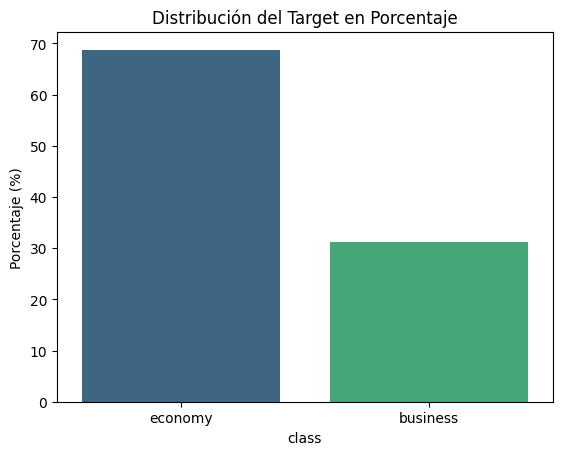

In [27]:
freq_vuelos = df_all_clean["class"].value_counts(normalize=True).mul(100).rename("percentage").reset_index()
sns.barplot(data=freq_vuelos, x="class", y="percentage", palette="viridis")
plt.ylabel("Porcentaje (%)")
plt.title("Distribución del Target en Porcentaje")
plt.show()

**Vamos a verificar outlier**

In [28]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd

class OutlierDetectorIQR(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.num_cols = None
        self.bounds = {}
    
    def fit(self, X, y=None):
        self.num_cols = X.select_dtypes(include=['int64', 'float64']).columns
        
        for col in self.num_cols:
            Q1 = X[col].quantile(0.25)
            Q3 = X[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 5 * IQR
            self.bounds[col] = (lower, upper)
        
        return self
    
    def transform(self, X):
        X_out = X.copy()
        X_out["is_outlier"] = False
        
        for col in self.num_cols:
            lower, upper = self.bounds[col]
            mask = (X[col] < lower) | (X[col] > upper)
            X_out["is_outlier"] = X_out["is_outlier"] | mask
        
        return X_out

In [29]:
from sklearn.pipeline import Pipeline

outlier_pipeline = Pipeline([
    ('outliers', OutlierDetectorIQR())
])

In [30]:
df_all_out = outlier_pipeline.fit_transform(df_all_clean)

In [31]:
df_all_out.head()

,airline,from,to,price (INR),class,duration(h),dep_time_cat,arr_time_cat,stop_num,days_left,is_outlier
0,Other,Delhi,Mumbai,5953.0,economy,2.166667,Evening,Night,0,1,True
1,Other,Delhi,Mumbai,5953.0,economy,2.333333,Early Morning,Morning,0,1,True
2,Other,Delhi,Mumbai,5956.0,economy,2.166667,Early Morning,Early Morning,0,1,True
3,Vistara,Delhi,Mumbai,5955.0,economy,2.250000,Morning,Afternoon,0,1,True
4,Vistara,Delhi,Mumbai,5955.0,economy,2.333333,Morning,Morning,0,1,True


In [32]:
df_all_out['is_outlier'].value_counts(normalize=True)

is_outlier
False    0.839875
True     0.160125
Name: proportion, dtype: float64

In [33]:
def boxplot_variable(df, col):
    plt.figure(figsize=(8,4))
    sns.boxplot(data=df, x=col, color='skyblue')
    plt.title(f"Boxplot de {col}")
    plt.show()


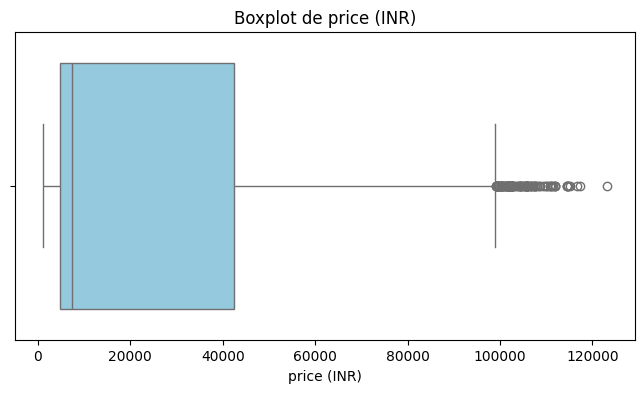

In [34]:
boxplot_variable(df_all_clean, 'price (INR)')

#### **Paso 3: Split Train y Test**

In [35]:
df_all_ml=df_all_clean.copy()

In [36]:
X=df_all_ml.drop(columns=["class"])
y=df_all_ml["class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [37]:
print(len(X_train))
print(len(X_test))

238553
59639


In [38]:
y_train.value_counts(normalize=True, dropna=False)

class
economy     0.687529
business    0.312471
Name: proportion, dtype: float64

In [39]:
y_test.value_counts(normalize=True, dropna=False)

class
economy     0.687537
business    0.312463
Name: proportion, dtype: float64

#### **Paso 4: Selección de features**

In [40]:
num_cols

['price (INR)', 'duration(h)', 'stop_num', 'days_left']

In [44]:
features_num_clas = ["duration(h)", "days_left", "stop_num" ] #"price (INR)"
print(features_num_clas)

features_cat_clas = [col for col in df_all_ml.columns if col not in features_num_clas and col != target]
features_cat_clas.remove("price (INR)")
print(features_cat_clas)

features = features_num_clas + features_cat_clas

['duration(h)', 'days_left', 'stop_num']
['airline', 'from', 'to', 'dep_time_cat', 'arr_time_cat']


In [63]:
features

['duration(h)',
 'days_left',
 'stop_num',
 'airline',
 'from',
 'to',
 'dep_time_cat',
 'arr_time_cat']

**Categóricas vs target_clas**

In [46]:
target

'class'

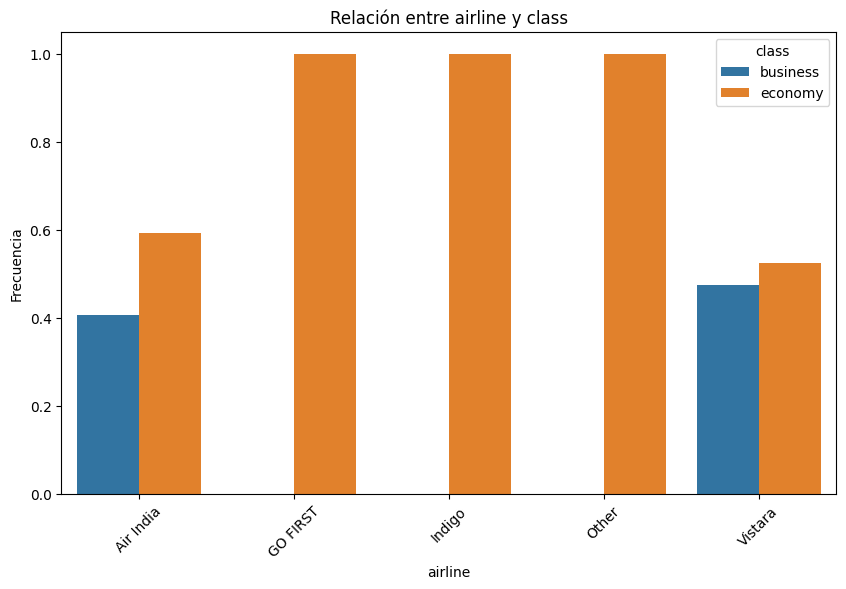

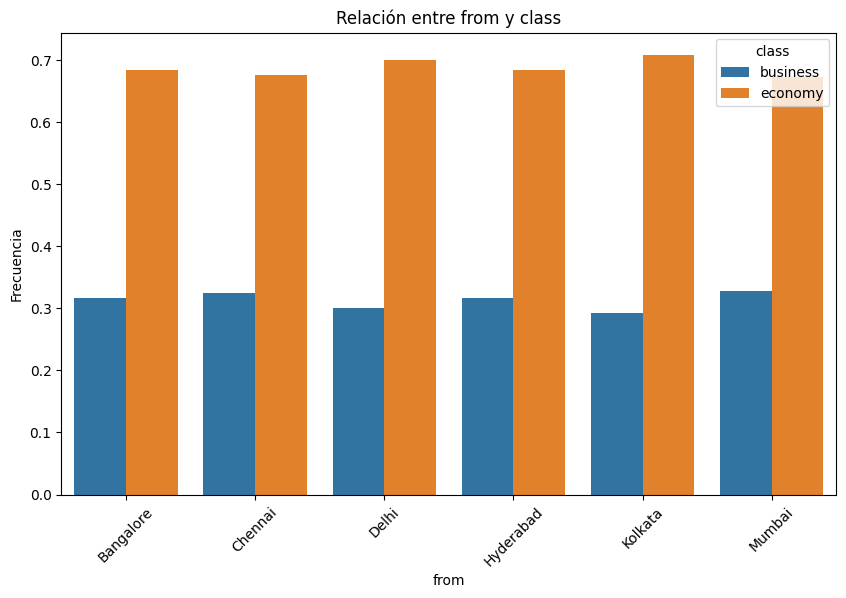

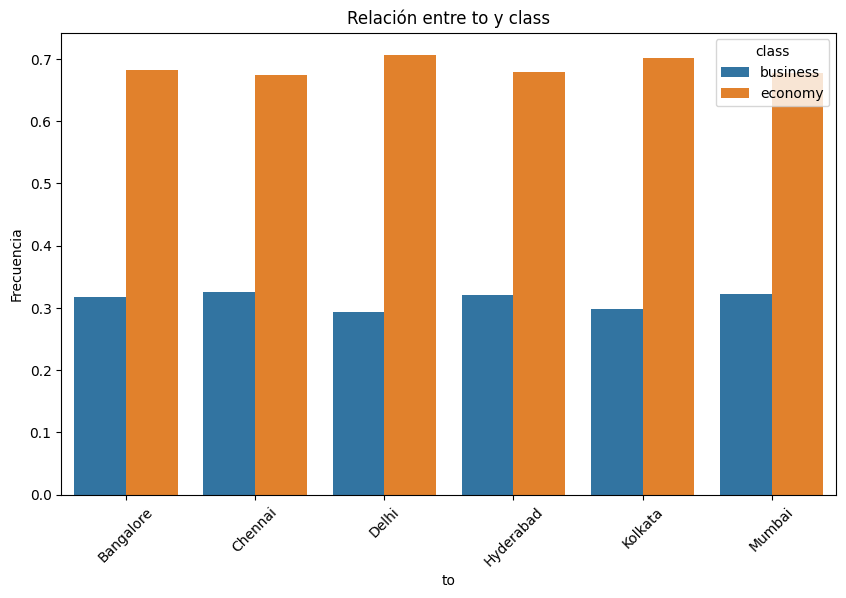

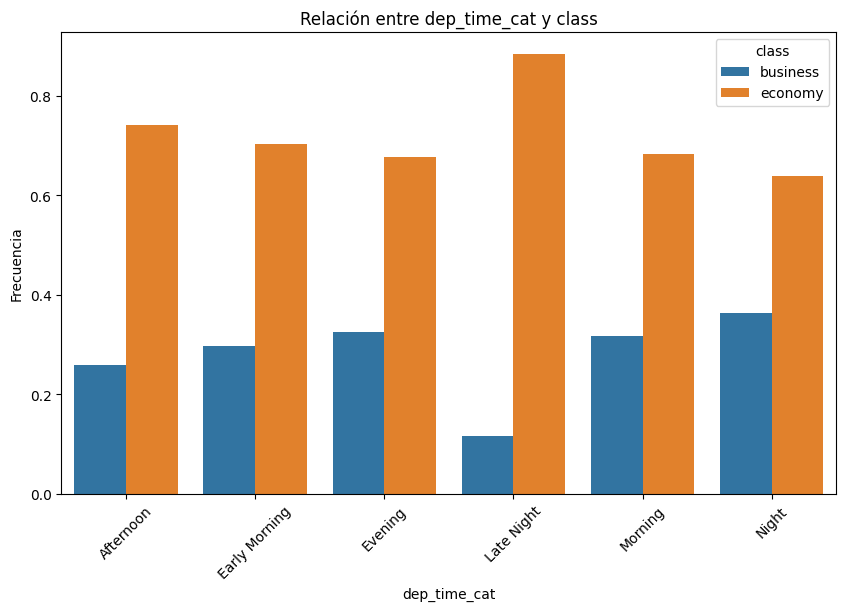

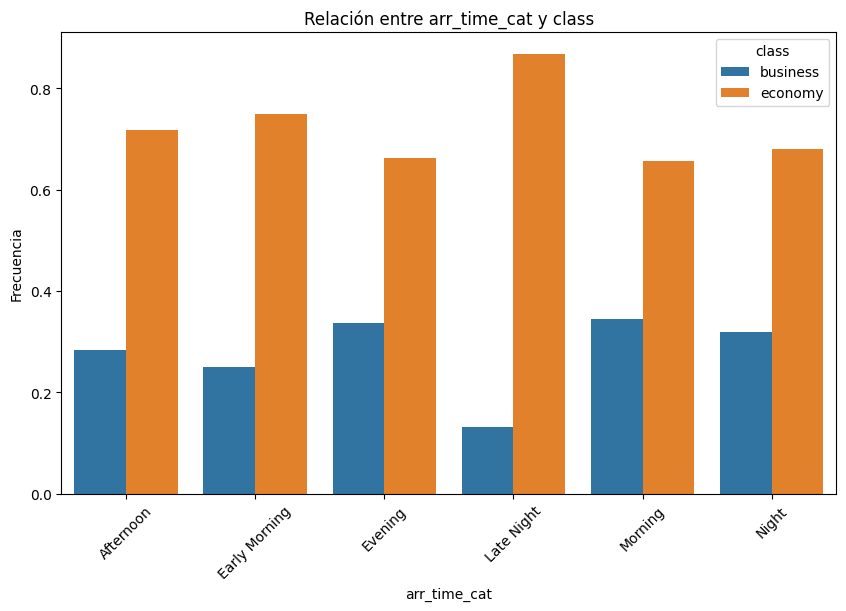

In [47]:
for col_cat in features_cat_clas:
    bt.plot_categorical_relationship_fin(df=df_all_ml, cat_col1=col_cat, cat_col2=target, size_group=6, relative_freq=True)

In [ ]:
#Parece haber cierta relación entre dept_time y arr_time y class

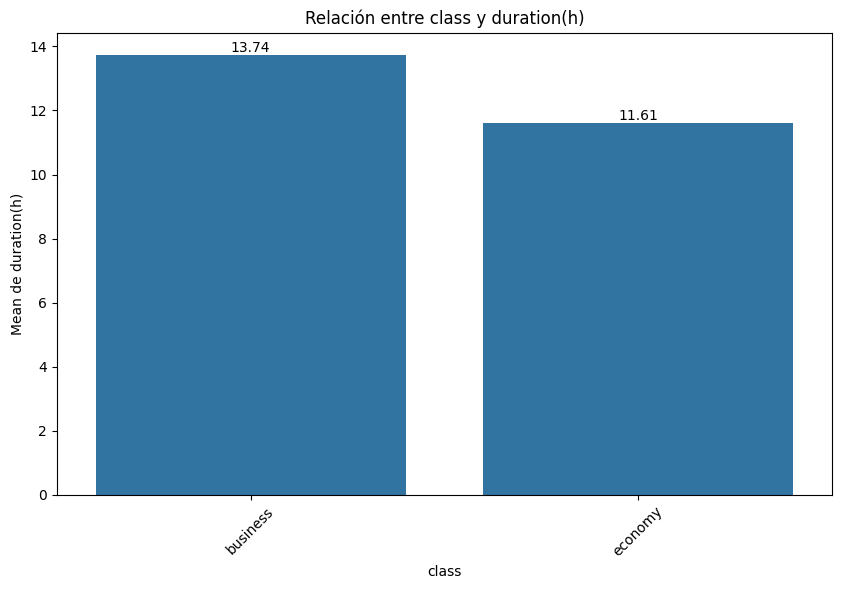

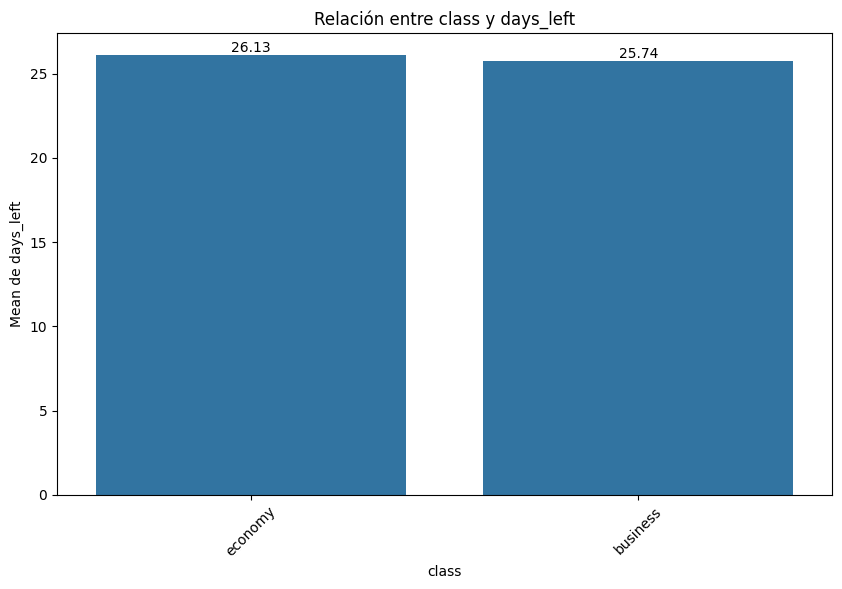

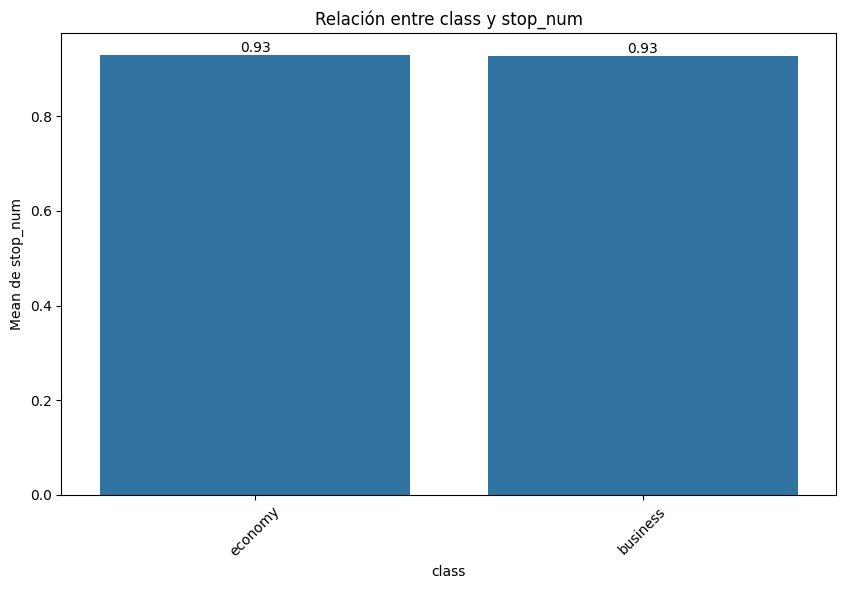

In [48]:
for col_num in features_num_clas:
    bt.plot_categorical_numerical_relationship(df=df_all_ml, numerical_col=col_num, show_values=True, categorical_col=target)

In [49]:
len(df_all_clean.columns)

10

In [50]:
features_cat_clas

['airline', 'from', 'to', 'dep_time_cat', 'arr_time_cat']

Aplico test estadistico Chi-cuadrado para determinar la relación del target con las variables categóricas

In [51]:
from scipy.stats import chi2_contingency

for col in features_cat_clas:
    contingency_table = pd.crosstab(df_all_ml[col], df_all_ml[target])
    chi2, p, dof, ex = chi2_contingency(contingency_table)
    print(f"Variable: {col} | p-value: {p:.5f}")

Variable: airline | p-value: 0.00000
Variable: from | p-value: 0.00000
Variable: to | p-value: 0.00000
Variable: dep_time_cat | p-value: 0.00000
Variable: arr_time_cat | p-value: 0.00000


Aplico test estadistico Anova para determinar la relación del target con las variables numéricas

In [52]:
features_num_clas

['duration(h)', 'days_left', 'stop_num']

In [53]:
target

'class'

In [54]:
for cat_col in features_num_clas:

    valores_unicos = df_all_ml[target].unique()
    target_por_cat_col = [df_all_ml[df_all_ml[target] == categoria][cat_col] for categoria in valores_unicos]
    f_val, p_val = stats.f_oneway(*target_por_cat_col)
    print(f"{cat_col}:")
    print(f"\t Valor de F: {f_val}")
    print(f"\t p-valor: {p_val}")

duration(h):
	 Valor de F: 5719.379056264566
	 p-valor: 0.0
days_left:
	 Valor de F: 52.98089308526964
	 p-valor: 3.376320029801002e-13
stop_num:
	 Valor de F: 2.1094149260609307
	 p-valor: 0.1463963316873553


In [55]:
features_num_clas

['duration(h)', 'days_left', 'stop_num']

In [56]:
features_cat_clas

['airline', 'from', 'to', 'dep_time_cat', 'arr_time_cat']

#### **Paso 5: Tratamiento de features y target**

In [ ]:
df_all_ml[features_num_clas].hist(bins=50)

In [ ]:
features_cat_clas

In [57]:
for col in features_cat_clas:
    print(f"Para la variable {col}")
    print(df_all_clean[col].value_counts(normalize=True))
    print("------------------------------")

Para la variable airline
airline
Vistara      0.425940
Air India    0.271241
Indigo       0.142613
Other        0.082977
GO FIRST     0.077229
Name: proportion, dtype: float64
------------------------------
Para la variable from
from
Delhi        0.203144
Mumbai       0.202286
Bangalore    0.173734
Kolkata      0.154961
Hyderabad    0.136680
Chennai      0.129195
Name: proportion, dtype: float64
------------------------------
Para la variable to
to
Mumbai       0.197145
Delhi        0.190589
Bangalore    0.169646
Kolkata      0.164981
Hyderabad    0.142864
Chennai      0.134776
Name: proportion, dtype: float64
------------------------------
Para la variable dep_time_cat
dep_time_cat
Morning          0.251368
Evening          0.216901
Early Morning    0.206910
Night            0.164696
Afternoon        0.156148
Late Night       0.003977
Name: proportion, dtype: float64
------------------------------
Para la variable arr_time_cat
arr_time_cat
Night            0.311021
Evening          0.

Aplicamos OneHotEncoder a las features categóricas través de ColumnTransformer:

In [58]:
from sklearn.preprocessing import OneHotEncoder

In [59]:
cat_cols = [col for col in features_cat_clas]

preprocessor_trees = ColumnTransformer([
    ("procesar_cat_OH", OneHotEncoder(handle_unknown = "ignore"), cat_cols)
], remainder = "passthrough")

# X_train_pre = preprocessor_trees.fit_transform(X_train)

Transformamos el target:

In [60]:
y_train = y_train.map({"economy": 0, "business": 1})
y_test = y_test.map({"economy": 0, "business": 1})

In [62]:
features

['duration(h)',
 'days_left',
 'stop_num',
 'airline',
 'from',
 'to',
 'dep_time_cat',
 'arr_time_cat']

In [64]:
X_train=X_train[features]
X_test=X_test[features]

#### **Paso 6: Baseline**

In [66]:
rf_clas = RandomForestClassifier(max_depth = 5, random_state= 42)

#### **Paso 7: Comparación modelos**

Randomforest

In [67]:
rf = Pipeline([
    ("prep", preprocessor_trees),
    ("model", RandomForestClassifier(
        max_depth = 5,
        random_state=42,
        n_jobs=-1
    ))
])

XGBoost

In [68]:
xgb = Pipeline([
    ("prep", preprocessor_trees),
    ("model", XGBClassifier(
        max_depth = 5,
        random_state=42,
        n_jobs=-1
    ))
])

LightGBM

In [83]:
lgbm = Pipeline([
    ("prep", preprocessor_trees),
    ("model", LGBMClassifier(
        max_depth = 7,
        random_state=42,
        verbose=-1
    ))
])

In [84]:
def eval_cv(model, X, y, name):
    scoring = {
    "f1_macro": "f1_macro",
    "balanced_accuracy" : "balanced_accuracy", 
    "roc_auc" : "roc_auc"
    #"precision" : "precision"
    #"recall" : "recall"
    
    }

    cv = cross_validate(
        model,
        X,
        y,
        cv=5,
        scoring=scoring,
        n_jobs=-1
    )

    print(f"\nModel <{name}>")
    print("f1_macro", cv["test_f1_macro"].mean())
    print("balanced_accuracy", cv["test_balanced_accuracy"].mean())
    print("roc_auc" , cv["test_roc_auc"].mean())


In [85]:
eval_cv(rf, X_train, y_train, "RF")
eval_cv(xgb, X_train, y_train, "XGB")
eval_cv(lgbm,X_train, y_train, "LGBM")


Model <RF>
f1_macro 0.407417435682189
balanced_accuracy 0.5
roc_auc 0.7650055576721243

Model <XGB>
f1_macro 0.6278704239283188
balanced_accuracy 0.6219783843976534
roc_auc 0.7906027672699135

Model <LGBM>
f1_macro 0.6111097709396088
balanced_accuracy 0.605997781485142
roc_auc 0.7855049922909862


Ajustamos los modelos

In [86]:
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)
lgbm.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('procesar_cat_OH', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta

In [87]:
def eval_test(model, X_test, y_test, name):
    preds = model.predict(X_test)

    probs = model.predict_proba(X_test)[:, 1]

    f1_macro = f1_score(y_test, preds, average='macro')
    bal_acc = balanced_accuracy_score(y_test, preds)
    roc_auc = roc_auc_score(y_test, probs)

    print(f"\n--- Clasificación: Resultados Test <{name}> ---")
    print(f"F1-Macro:          {f1_macro:.4f}")
    print(f"Balanced Accuracy: {bal_acc:.4f}")
    print(f"ROC-AUC:           {roc_auc:.4f}")

In [88]:
eval_test(rf, X_test, y_test, "RF")
eval_test(xgb, X_test, y_test, "XGB")
eval_test(lgbm, X_test, y_test, "LGBM")


--- Clasificación: Resultados Test <RF> ---
F1-Macro:          0.4074
Balanced Accuracy: 0.5000
ROC-AUC:           0.7655

--- Clasificación: Resultados Test <XGB> ---
F1-Macro:          0.6334
Balanced Accuracy: 0.6273
ROC-AUC:           0.7949


c:\Users\aquin\Desktop\Bootcamp_DS\DS-Online_AQR\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



--- Clasificación: Resultados Test <LGBM> ---
F1-Macro:          0.6142
Balanced Accuracy: 0.6087
ROC-AUC:           0.7882


c:\Users\aquin\Desktop\Bootcamp_DS\DS-Online_AQR\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [89]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

def plot_cm(model, X_test, y_test, name):
    # 1. Predecir
    y_pred = model.predict(X_test)
    
    # 2. Calcular la matriz
    cm = confusion_matrix(y_test, y_pred)
    
    # 3. Visualizar con Seaborn para que sea legible
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Economy (0)', 'Business (1)'], 
                yticklabels=['Economy (0)', 'Business (1)'])
    
    plt.title(f'Matriz de Confusión - {name}')
    plt.xlabel('Predicción del Modelo')
    plt.ylabel('Clase Real (Target)')
    plt.show()

c:\Users\aquin\Desktop\Bootcamp_DS\DS-Online_AQR\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


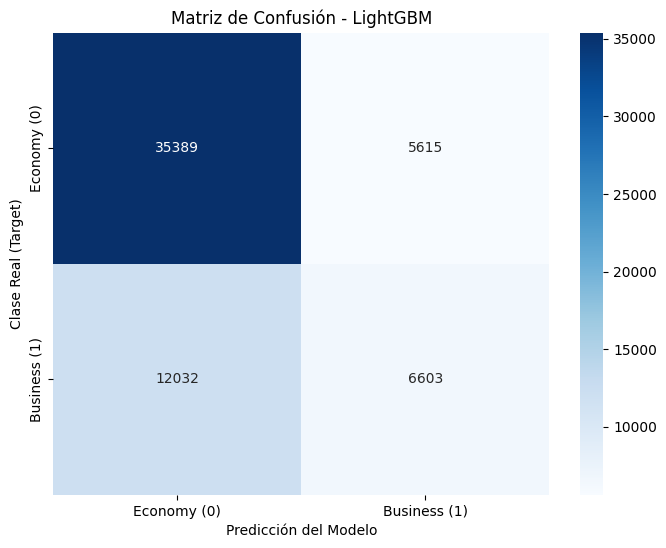

In [91]:
plot_cm(lgbm, X_test, y_test, "LightGBM")

#### **Paso 8: Optimización con optuna**

In [97]:
import optuna
from sklearn.model_selection import cross_val_score

In [92]:
# Definir función objetivo para Optuna

def objective(trial):

    param_grid = {
        "model__n_estimators": trial.suggest_int("model__n_estimators", 100, 1000),
        "model__max_depth": trial.suggest_int("model__max_depth", 4, 12), # Subimos profundidad para captar patrones sin precio
        "model__learning_rate": trial.suggest_float("model__learning_rate", 0.01, 0.2, log=True),
        "model__subsample": trial.suggest_float("model__subsample", 0.6, 1.0),
        "model__colsample_bytree": trial.suggest_float("model__colsample_bytree", 0.6, 1.0),
        # Añadimos este para manejar el desbalanceo del 30% Business
        "model__scale_pos_weight": trial.suggest_float("model__scale_pos_weight", 1.0, 3.0)
        }


    xgb.set_params(**param_grid)

    score = cross_val_score(
        xgb,
        X_train,
        y_train,
        cv=5,
        scoring="f1_macro", 
        n_jobs=-1
    ).mean()

    return score

In [98]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("Mejores parámetros:", study.best_params)
print("Mejor F1-Macro:", study.best_value)

[I 2026-03-02 23:25:41,951] A new study created in memory with name: no-name-b4c70084-8f14-4e85-8df0-7cedbef96472
[I 2026-03-02 23:26:39,962] Trial 0 finished with value: 0.69894378611122 and parameters: {'model__n_estimators': 732, 'model__max_depth': 5, 'model__learning_rate': 0.11444864761931103, 'model__subsample': 0.8745321882205246, 'model__colsample_bytree': 0.8644852358057494, 'model__scale_pos_weight': 1.838230745471717}. Best is trial 0 with value: 0.69894378611122.
[I 2026-03-02 23:27:45,911] Trial 1 finished with value: 0.6915655179478764 and parameters: {'model__n_estimators': 469, 'model__max_depth': 11, 'model__learning_rate': 0.044200659447961456, 'model__subsample': 0.8291521834699123, 'model__colsample_bytree': 0.8643250777648377, 'model__scale_pos_weight': 1.924963415583123}. Best is trial 0 with value: 0.69894378611122.
[I 2026-03-02 23:28:28,761] Trial 2 finished with value: 0.7027760980842803 and parameters: {'model__n_estimators': 394, 'model__max_depth': 11, 'mo

KeyboardInterrupt: 